<h1><center>TD1 - Notebook 3 : Comment les caractéristiques d'un bassin versant modifient le débit du cours d'eau ? Approche par une modélisation hydrogéologique </center></h1>

### 1. Charger les librairies python

In [1]:
# Libraries installed by default
import sys
import glob
import os
import fnmatch
import random
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", message=".*An exception was ignored while fetching the attribute.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*`np.object` is a deprecated alias for the builtin `object`.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated. Use tobytes().*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated since Matplotlib 3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".* .*", category=DeprecationWarning)
# Libraries need to be installed if not
import numpy as np
import pandas as pd
import shutil
from geopy.geocoders import Nominatim
# Libraries added from 'conda install' procedure
import geopandas as gpd
import matplotlib as mpl        # install automatically by geopandas
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.pylab as pl
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Libraries added from 'conda forge' procedure
from osgeo import gdal, osr # or import gdal
import rasterio
# Libraries installed from the pip procedure
import deepdish as dd
import flopy
import imageio
import vedo
import hydroeval
import xarray	
import netCDF4
import matplotlib_scalebar	
import contextily
import pyproj # uninstall before install
import selenium
import shapefile # named pyshp for install
import jupyter
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\whitebox\whitebox_tools.py:47: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references

### 2. Renseigner les répertoires utilisés et importer les classes Hydromodpy utilisées

#### Répertoire d'Hydromodpy

In [2]:
root_dir = 'C:/Users/camil/Documents/GitHub/HydroModPy'
sys.path.append(root_dir)
cwd = os.getcwd()
if not cwd == root_dir:
    os.chdir(root_dir)
    print("Root path directory is: {0}".format(cwd))

Root path directory is: C:\Users\camil\Documents\GitHub\HydroModPy\teaching


#### Importer les fichiers source Hydromodpy

In [3]:
import src # import the folder src from HydroModpy codes
import importlib # 
importlib.reload(src)
# import all the classes necessary to extract the watershed from Hydromodpy source files.
from src import watershed_root
from src.watershed import climatic, geographic, geology, geometric, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

#### Répertoire des données utilisées dans ce TD

In [4]:
teaching_path = root_dir + "/teaching/"
data_path = teaching_path + "/data/"
# complete where modflow sources are
modflow_path = os.path.join(root_dir,'bin/')
#
watershed_name = 'Glueyre'

#### Répertoire des résultats créés dans ce TD

In [5]:
out_path = 'C:/Users/camil/Documents/GitHub/HydroModPy'
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/'

### 3. Charger l'objet Bassin Versant déjà créé

In [6]:
print('##### '+watershed_name.upper()+' #####')
load=True
BV = watershed_root.Watershed(dem_path='',
                              out_path=root_dir,
                              load=load,
                              watershed_name=watershed_name,
                              save_object=False)

##### GLUEYRE #####
      __  __          __           __  ____          ________     
     / / / /         / /          /  \/   /         / / __  /     
    / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
   / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
  / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
 /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
       /____/ Hydrological Modelling in Python /_____________/    
                                                                  
Object was loaded successfully


### 4. Extraire les données de forçage climatique qui seront utilisées pour la modélisation

#### Initialization du module climatique à partir des données de recharge et de runoff disponible dans votre dossier de données

In [7]:
BV.add_climatic()
BV.climatic.update_recharge_reanalysis(path_file=data_path+'_climate_REANALYSIS_mperday.csv',
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')
BV.climatic.update_runoff_reanalysis(path_file=data_path+'_climate_REANALYSIS_mperday.csv',
                                     clim_mod='REA',
                                     clim_sce='historic',
                                     first_year=1990,
                                     last_year=2019,
                                     time_step='D',
                                     sim_state='transient')
#print(BV.climatic.recharge)

Init climatic module to set model parameter


#### Visualisation des données climatiques

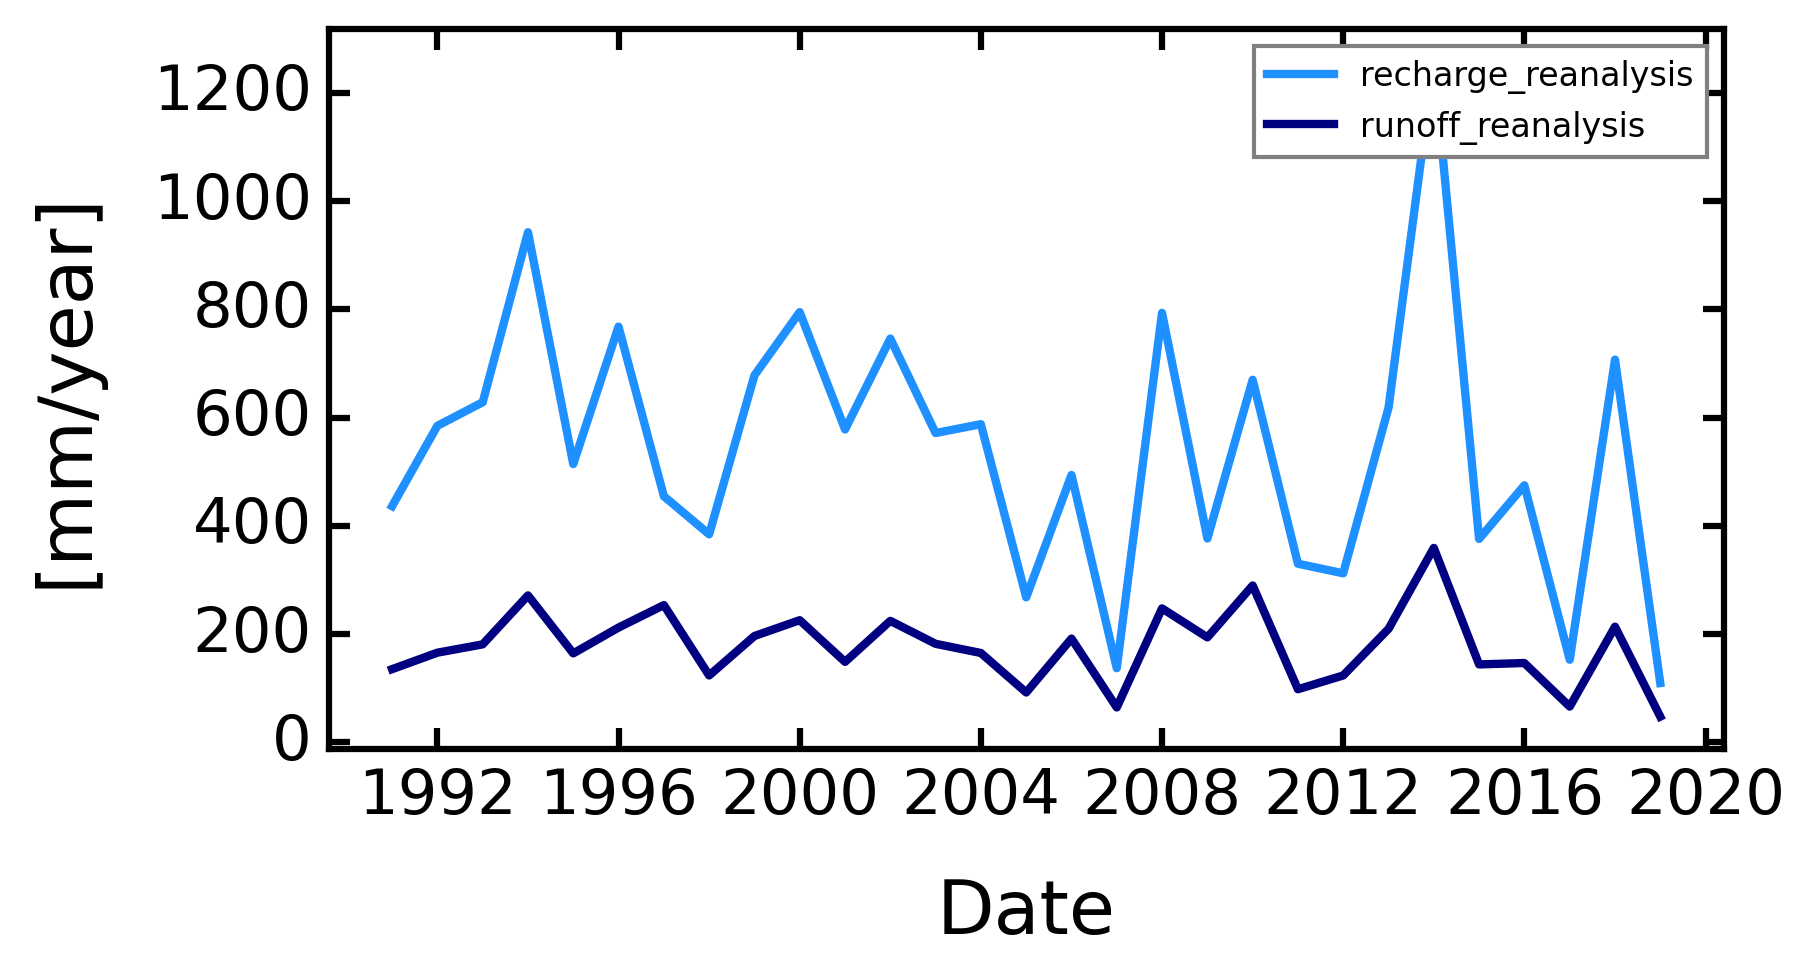

In [8]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
R = BV.climatic.recharge.resample('Y').sum()*1000
r = BV.climatic.runoff.resample('Y').sum()*1000
ax.plot(R, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[mm/year]')
ax.legend()

### 4. Donner les caractéristiques de l'aquifère modélisé et initialisation du modèle

In [9]:
sim_state = 'transient' # 'steady' or 'transient'

box = True # or False
sink_fill = False # or True
plot_cross = False
first_clim = 'mean'
nlay = 1
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant auifer thickness, or 2D matrix
thick = 50 # if bottom is None, aquifer thickness
cond_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
verti_cond = None # or [ [1e-5, [0, 20]],
                  #      [1e-6, [20,80]] ]
cond_drain = None # or value of conductance
poro_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL

# Particle tracking settings
zone_partic = 'domain' # or watershed

In [10]:
BV.add_settings()
BV.add_geometric() # soon
BV.add_hydraulic()

BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_active_plot(plot_cross=plot_cross)

BV.climatic.update_first_clim(first_clim)

BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None

BV.hydraulic.update_cond_vertical(verti_cond)
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_lay_decay(poro_decay)

BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)

BV.settings.update_input_particules(zone_partic=zone_partic)

Init settings module to set model parameter
Init hydraulic module to set model parameter


In [11]:
porosity = 10 / 100 # -
hyd_cond = 5e-4 * 24 * 3600 #
BV.hydraulic.update_porosity(porosity)
BV.hydraulic.update_hyd_cond(hyd_cond)

recharge_values = toolbox.select_period(BV.climatic.recharge, 2000, 2000) # in m/day
print(recharge_values)
BV.climatic.update_recharge(recharge_values[:12], sim_state='transient')

Datetime
2000-01-01    0.004128
2000-01-02    0.004235
2000-01-03    0.006143
2000-01-04    0.007288
2000-01-05    0.007197
                ...   
2000-12-27    0.000327
2000-12-28    0.000317
2000-12-29    0.000308
2000-12-30    0.000300
2000-12-31    0.000292
Freq: D, Name: REC_REA_historic, Length: 366, dtype: float64


Ici la période de la recharge est importante car on est en régime transitoire, donc les résultats vont être calculés à chaque pas de temps défini par la recharge.

#### On fait tourner le modèle

In [12]:
set_simulations = 'transient_sensitivity'

model_name = set_simulations+'_k_'+str(round(hyd_cond,3))+'_porosity_'+str(round(porosity,2))+'_rech_'+str(round(recharge_values.mean(),2))
BV.settings.update_model_name(model_name)
print(model_name)

model_modflow = BV.preprocessing_modflow(simulations_folder)
success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)
if success_modflow == True:
    BV.postprocessing_modflow(model_modflow,
                              watertable_elevation = True,
                              watertable_depth= True, 
                              seepage_areas = True,
                              outflow_drain = True,
                              groundwater_flux = True,
                              groundwater_storage = True,
                              accumulation_flux = True,
                              export_all_tif = True)

transient_sensitivity_k_43.2_porosity_0.1_rech_0.0
FloPy is using the following executable to run the model: C:\Users\camil\Documents\GitHub\HydroModPy\bin/win\mfnwt.exe

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: transient_sensitivity_k_43.2_porosity_0.1_rech_0.0.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2023/12/19 11:49:20

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     3    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:    

Tous les résultats sont enregistrés dans le dossier, vous pouvez utiliser les rasters générés pour voir l'évolution du bassin versant au cours du temps.

#### Résultats du modèle en carte

Ici vous pouvez modifier le numéro entre parenthèses dans watertable_elevation_t(0).tif pour plotter les cartes à différents pas de temps.

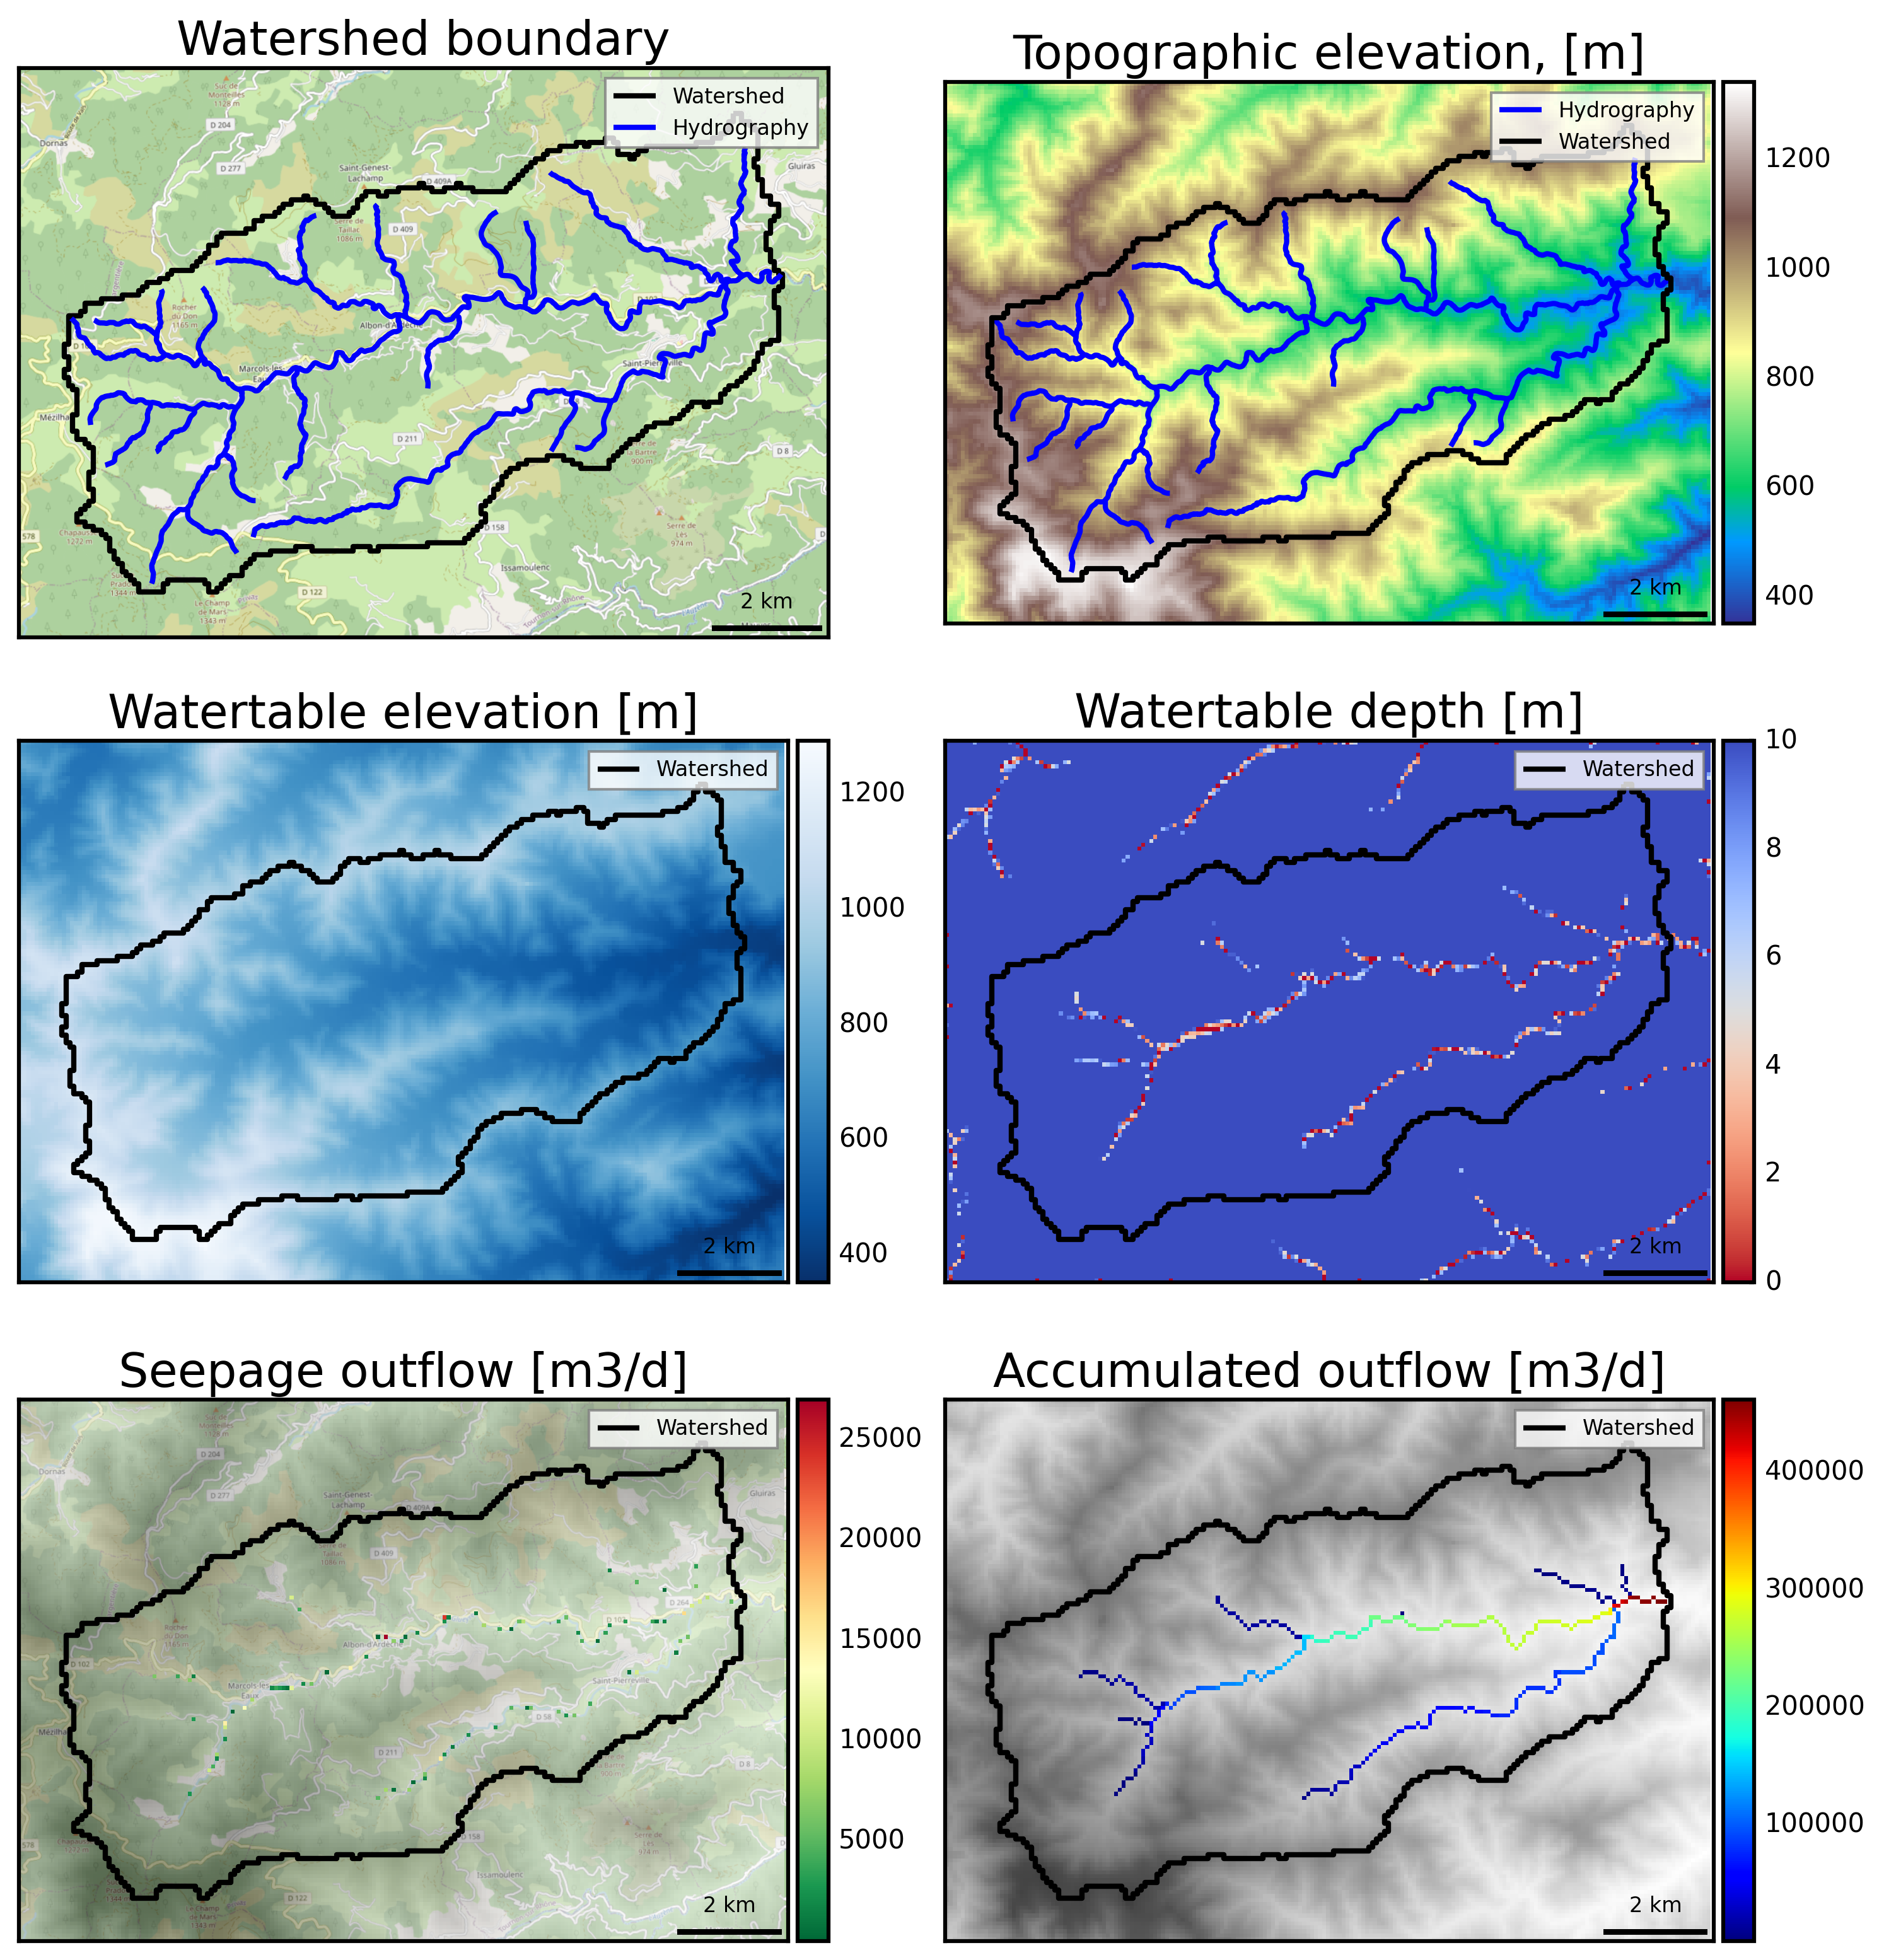

In [13]:
dem_data = imageio.imread(stable_folder+'/geographic/'+'watershed_box_buff_dem.tif') # dem data
stream_data = imageio.imread(stable_folder+'/hydrography/'+'cours_eau_V.tif') # river data
watertable_data = imageio.imread(simulations_folder+model_name+'/_postprocess/_rasters/'+'watertable_elevation_t(0).tif') # watertable data
visu = visualization_results.Visualization(BV, model_name)
visu.visual2D(object_list = ['map','grid',
                             'watertable', 'watertable_depth',
                             'drain_flow','surface_flow',
                             #'pathlines', 'residence_times'
                             ],
              color_scale = [(None,None),(None,None),
                             (None,None),(0,10),
                             (None,None),(None,None),
                             #(None,None),(None,None),
                             ], 
              lines=100)

#### Résultats quantitatifs du modèle à chaque pas de temps

In [14]:
timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=None,
                                                  actual_date=True, 
                                                  subbasin_results=False)
timeseries = pd.read_csv(simulations_folder+model_name+'/_postprocess/'+'_timeseries/'+'_simulated_timeseries.csv', sep=';')
print(timeseries)

Extract modflow and modpath results in timeseries
          date  recharge  watertable_elevation  watertable_depth  \
0   2000-01-01  0.004128               805.160           45.3273   
1   2000-01-02  0.004235               805.137           45.3497   
2   2000-01-03  0.006143               805.134           45.3531   
3   2000-01-04  0.007288               805.142           45.3454   
4   2000-01-05  0.007197               805.148           45.3391   
5   2000-01-06  0.006968               805.152           45.3352   
6   2000-01-07  0.008022               805.165           45.3215   
7   2000-01-08  0.008270               805.181           45.3062   
8   2000-01-09  0.007236               805.186           45.3014   
9   2000-01-10  0.006551               805.184           45.3032   
10  2000-01-11  0.006802               805.184           45.3026   
11  2000-01-12  0.006495               805.182           45.3048   

    seepage_areas  outflow_drain  groundwater_flux  groundwater_s

**Vous pouvez tracer l'évolution des variables hydrologiques de bassin versant au cours du temps (débit, hauteur de la nappe..). Comment doit-on calculer le débit à l'exutoire simulé?**

**Comme pour le TD précédent, vous pouvez faire varier les paramètres du modèle et voir ce que cela change sur le débit simulé.**

**Est ce que vous pensez que la période de simulation choisie est pertinente? Comment pourriez vous choisir une autre période de simulation, sans trop augmenter le temps de calcul?**

In [17]:
BV.climatic.update_recharge_reanalysis(path_file=data_path+'_climate_REANALYSIS_mperday.csv',
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')
BV.climatic.update_runoff_reanalysis(path_file=data_path+'_climate_REANALYSIS_mperday.csv',
                                     clim_mod='REA',
                                     clim_sce='historic',
                                     first_year=1990,
                                     last_year=2019,
                                     time_step='D',
                                     sim_state='transient')

R = BV.climatic.recharge.resample('M').sum() /1000
r = BV.climatic.runoff.resample('M').sum() /1000
recharge = R.copy()
BV.climatic.update_recharge(recharge, sim_state=sim_state)

In [18]:
print(R)

Datetime
1990-01-31    0.000051
1990-02-28    0.000015
1990-03-31    0.000144
1990-04-30    0.000036
1990-05-31    0.000014
                ...   
2018-03-31    0.000018
2018-04-30    0.000014
2018-05-31    0.000022
2018-06-30    0.000004
2018-07-31    0.000002
Freq: M, Name: REC_REA_historic, Length: 343, dtype: float64
